In [1]:
#import
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False


from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
import shap, pandas as pd, numpy as np, matplotlib.pyplot as plt


In [10]:
# load train and test data
data = np.load("mushroom_train_test.npz", allow_pickle=True)
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
feat_names = data["feat_names"].tolist()

print(f"Loaded shapes: X_train={X_train.shape}, X_test={X_test.shape}")
if 'feat_names' in globals() and isinstance(feat_names, (list, tuple)) and len(feat_names) == X_train.shape[1]:
    colnames = list(feat_names)
else:
    colnames = [f"f{i}" for i in range(X_train.shape[1])]
X_train_df = pd.DataFrame(X_train, columns=colnames)
X_test_df  = pd.DataFrame(X_test,  columns=colnames)
cat_cols = X_train_df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X_train_df.select_dtypes(include=["number"]).columns.tolist()

Loaded shapes: X_train=(48855, 16), X_test=(12214, 16)


In [12]:
#evaluation function (will be reerun for each model)
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def evaluate_and_log(model_name, estimator, X_tr=X_train, X_te=X_test):
    y_pred = estimator.predict(X_te)

    #probability scores for ROC
    if hasattr(estimator, "predict_proba"): #if model accepts probability caluclation, use it
        y_proba = estimator.predict_proba(X_te)[:, 1]
    elif hasattr(estimator, "decision_function"): #otherwise calculate distance from descions boundary (semi probability)
        s = estimator.decision_function(X_te)
        s_min, s_max = s.min(), s.max()
        y_proba = (s - s_min) / (s_max - s_min + 1e-12)
    else: #if model doesnt accept either calculation just use the 1/0 prediction
        y_proba = y_pred.astype(float)

    roc  = roc_auc_score(y_test, y_proba) #use the probability to calculate ROC
    #then do other metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {model_name} Performance ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}\n")

    print("Full Report:\n")
    print(classification_report(y_test, y_pred, target_names=["Edible (0)", "Poisonous (1)"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=["True: Edible (0)", "True: Poisonous (1)"],
                         columns=["Pred: Edible (0)", "Pred: Poisonous (1)"])
    print("Confusion Matrix:")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
                cbar=False, linewidths=1, linecolor='gray',
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f"{model_name} - Confusion Matrix", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.show()



=== CatBoost Performance ===
Accuracy : 0.9998
Precision: 1.0000
Recall   : 0.9997
F1-score : 0.9999
ROC AUC  : 1.0000

Full Report:

               precision    recall  f1-score   support

   Edible (0)     0.9996    1.0000    0.9998      5436
Poisonous (1)     1.0000    0.9997    0.9999      6778

     accuracy                         0.9998     12214
    macro avg     0.9998    0.9999    0.9998     12214
 weighted avg     0.9998    0.9998    0.9998     12214

Confusion Matrix:


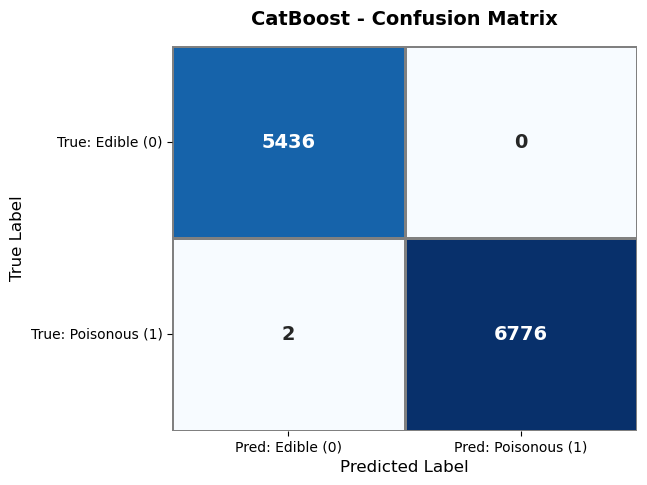

In [13]:
# --- CatBoost categorical fix: make cats strings and replace NaN with a sentinel ---
X_train_cb = X_train_df.copy()
X_test_cb  = X_test_df.copy()

# 1) ensure all categorical columns are string-typed and have no float NaNs
SENTINEL = "__MISSING__"
for c in cat_cols:
    # Cast to string first; this turns numbers into '42' etc., and NaN -> 'nan'
    X_train_cb[c] = X_train_cb[c].astype("string")
    X_test_cb[c]  = X_test_cb[c].astype("string")
    # Replace <NA>/NaN/"<NA>" with a single sentinel token that CatBoost treats as a valid category
    X_train_cb[c] = X_train_cb[c].fillna(SENTINEL).replace({"<NA>": SENTINEL, "nan": SENTINEL, "NaN": SENTINEL})
    X_test_cb[c]  = X_test_cb[c].fillna(SENTINEL).replace({"<NA>": SENTINEL, "nan": SENTINEL, "NaN": SENTINEL})

# 2) build categorical feature indices for CatBoost (positions in the DataFrame)
cat_idx = [X_train_cb.columns.get_loc(c) for c in cat_cols]

# 3) (optional but robust) use Pool objects
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train_cb, y_train, cat_features=cat_idx)
test_pool  = Pool(X_test_cb,  y_test,  cat_features=cat_idx)

# 4) fit
cat = CatBoostClassifier(
    depth=8, learning_rate=0.1, iterations=1000,
    loss_function="Logloss", verbose=False, random_state=42
)
cat.fit(train_pool, eval_set=test_pool, verbose=False)
evaluate_and_log("CatBoost", cat, X_tr=X_train_cb, X_te=X_test_cb)


{'Model': 'Baseline', 'Accuracy': 0.9999181267398067, 'Precision': 1.0, 'Recall': 0.9998524638536441, 'F1': 0.999926226484692, 'ROC_AUC': 0.9999999457188572}


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.999918,1.000000,0.999852,0.999926,1.000000
1,Missing 10%,0.957098,0.973071,0.948952,0.960860,0.993530
2,Missing 30%,0.834534,0.906929,0.782089,0.839895,0.930084
3,Missing 50%,0.688308,0.837844,0.543523,0.659329,0.798672


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.999918,1.000000,0.999852,0.999926,1.000000
1,Cat 20%,0.999918,1.000000,0.999852,0.999926,1.000000
2,Noise 10%,0.992713,0.990756,0.996164,0.993453,0.999718
3,Both mild,0.999591,0.999705,0.999557,0.999631,1.000000
4,Both heavy,0.944081,0.932208,0.969755,0.950611,0.989701


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.999918,1.000000,0.999852,0.999926,1.000000
1,Drop 1,0.999263,0.999557,0.999115,0.999336,0.999997
2,Drop 3,0.996479,0.996462,0.997197,0.996829,0.999830
3,Drop 5,0.992795,0.992491,0.994541,0.993515,0.999538


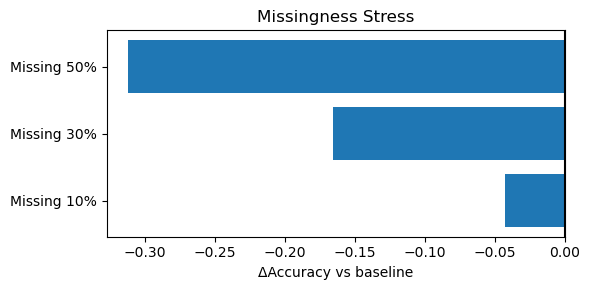

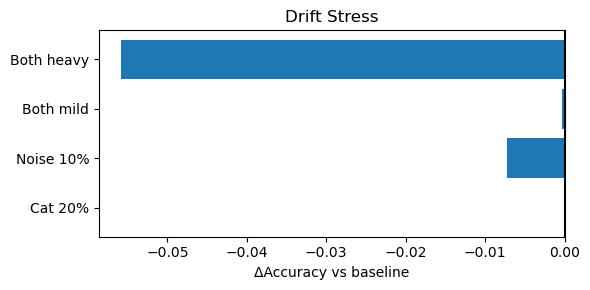

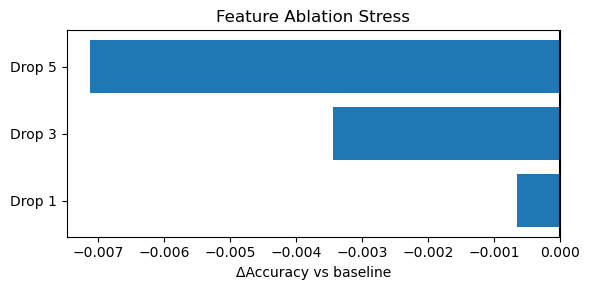

In [14]:
# ============================================
# 4) ROBUSTNESS & STRESS TESTS
# ============================================
# This section evaluates how stable your top model (Random Forest)
# is under simulated data degradation:
#  - Randomly missing values at inference time
#  - Artificial drift (categorical shuffling, numeric noise)
#  - Feature ablation (dropping top-k important features)

from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- define preprocessing identical to your main setup ---
def make_preprocessor(cat_cols, num_cols):
    return ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), cat_cols),
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols)
    ])

# --- convenience: train+eval function returning metrics ---
def fit_and_eval(pipe, Xtr, ytr, Xte, yte, name=""):
    pipe.fit(Xtr, ytr)
    y_pred = pipe.predict(Xte)
    y_proba = pipe.predict_proba(Xte)[:,1]
    return dict(
        Model=name,
        Accuracy=accuracy_score(yte, y_pred),
        Precision=precision_score(yte, y_pred),
        Recall=recall_score(yte, y_pred),
        F1=f1_score(yte, y_pred),
        ROC_AUC=roc_auc_score(yte, y_proba)
    )

# --- baseline model (RF) ---
pre = make_preprocessor(cat_cols, num_cols)
rf = RandomForestClassifier(n_estimators=200, max_features="sqrt", random_state=42, n_jobs=-1)
baseline_pipe = Pipeline([("pre", pre), ("clf", rf)])
baseline_metrics = fit_and_eval(baseline_pipe, X_train_df, y_train, X_test_df, y_test, "Baseline")
print(baseline_metrics)

# ---------- Stress 1: Missingness ----------
# Randomly set a fraction of values to NaN in test set
def inject_missing(df, frac):
    df2 = df.copy()
    n = len(df2)
    rng = np.random.RandomState(42)
    for c in df2.columns:
        idx = rng.choice(n, size=int(frac*n), replace=False)
        df2.loc[df2.index[idx], c] = np.nan
    return df2

miss_fracs = [0.1, 0.3, 0.5]
miss_results = [baseline_metrics]
for frac in miss_fracs:
    Xmiss = inject_missing(X_test_df, frac)
    miss_results.append(fit_and_eval(baseline_pipe, X_train_df, y_train, Xmiss, y_test, f"Missing {frac:.0%}"))
miss_df = pd.DataFrame(miss_results)
display(miss_df)

# ---------- Stress 2: Drift ----------
# Introduce (a) category swaps, (b) numeric noise to simulate data drift
def perturb_categories(df, frac):
    df2 = df.copy()
    rng = np.random.RandomState(42)
    for c in cat_cols:
        vals = df2[c].dropna().unique()
        if len(vals) > 1:
            idx = rng.choice(len(df2), size=int(frac*len(df2)), replace=False)
            df2.loc[df2.index[idx], c] = rng.choice(vals, size=len(idx))
    return df2

def add_numeric_noise(df, std_frac):
    df2 = df.copy()
    rng = np.random.RandomState(42)
    for c in num_cols:
        sig = df2[c].std()
        df2[c] = df2[c] + rng.normal(0, std_frac*sig, size=len(df2))
    return df2

drift_cfgs = [
    ("Cat 20%", 0.2, 0.0),
    ("Noise 10%", 0.0, 0.1),
    ("Both mild", 0.1, 0.05),
    ("Both heavy", 0.3, 0.2),
]
drift_results = [baseline_metrics]
for name, cfrac, nfrac in drift_cfgs:
    Xd = X_test_df.copy()
    if cfrac: Xd = perturb_categories(Xd, cfrac)
    if nfrac: Xd = add_numeric_noise(Xd, nfrac)
    drift_results.append(fit_and_eval(baseline_pipe, X_train_df, y_train, Xd, y_test, name))
drift_df = pd.DataFrame(drift_results)
display(drift_df)

# ---------- Stress 3: Feature ablation ----------
# Drop top-k important features (permutation importance)
perm = permutation_importance(baseline_pipe, X_test_df, y_test, n_repeats=5, random_state=42, scoring="roc_auc")
feat_imp = pd.Series(perm.importances_mean, index=X_test_df.columns).sort_values(ascending=False)
top_feats = feat_imp.index.tolist()

def drop_and_retrain(drop_cols):
    Xtr, Xte = X_train_df.drop(columns=drop_cols), X_test_df.drop(columns=drop_cols)
    cat2 = [c for c in cat_cols if c not in drop_cols]
    num2 = [c for c in num_cols if c not in drop_cols]
    pipe = Pipeline([("pre", make_preprocessor(cat2, num2)), ("clf", rf)])
    return fit_and_eval(pipe, Xtr, y_train, Xte, y_test, f"Drop {len(drop_cols)}")

abl_results = [baseline_metrics]
for k in [1,3,5]:
    abl_results.append(drop_and_retrain(top_feats[:k]))
ablate_df = pd.DataFrame(abl_results)
display(ablate_df)

# --- quick plots: visualize accuracy drops for each stress test ---
def plot_delta(df, title):
    base = df.iloc[0]["Accuracy"]
    delta = df.copy()
    delta["ΔAcc"] = delta["Accuracy"] - base
    plt.figure(figsize=(6,3))
    plt.barh(delta["Model"][1:], delta["ΔAcc"][1:])
    plt.axvline(0, color="k")
    plt.title(title); plt.xlabel("ΔAccuracy vs baseline"); plt.tight_layout(); plt.show()

plot_delta(miss_df, "Missingness Stress")
plot_delta(drift_df, "Drift Stress")
plot_delta(ablate_df, "Feature Ablation Stress")


grapg accuracy across epochs and run on raw dataset